In [ ]:
# imports
import numpy as np
import pandas as pd
from scipy.integrate import quad

from sympy import *
u0, u1, u2, u3, u4 = symbols('u0 u1 u2 u3 u4')
c = symbols('c')
init_printing(use_unicode=True)

In [ ]:
# Define size of system
M=3
n=int((M+1)/2)
chi = (n+1)/(2*n)

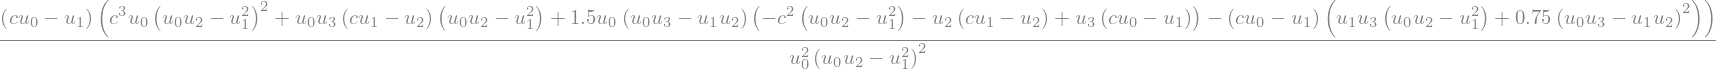

In [ ]:
# Substitutes for the characteristic polynomial
sigma11 = u2 - u1 * u1 / u0
sigma12 = u3 - u2 * u1 / u0
# Closure
u4 = u3 * u1 / u0 + chi * (u3 - (u2*u1)/u0)**2 / (u2 - u1*u1/u0)

# Characteristic polynomial
P_expr = (
    c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]     # p_{n-1}(c)
) * (
    (
        c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_tilde_{n+1}
    ) - 2 * chi * sigma12 / sigma11 * (
        c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]  # p_n(c)
    )
)
P = simplify(P_expr)
P

In [ ]:
# Bimodal distribution
def fbimodal(rho1_bimodal, v1_bimodal, theta1_bimodal, rho2_bimodal, v2_bimodal, theta2_bimodal, c):
    term1 = (rho1_bimodal / np.sqrt(2 * np.pi * theta1_bimodal)) * np.exp(-(c - v1_bimodal) ** 2 / (2 * theta1_bimodal))
    term2 = (rho2_bimodal / np.sqrt(2 * np.pi * theta2_bimodal)) * np.exp(-(c - v2_bimodal) ** 2 / (2 * theta2_bimodal))
    return term1 + term2

# --- fixed parameters ---
rho1_bimodal = 40 / 100
v1_bimodal = 0
theta1_bimodal = 100 / 100
rho2_bimodal = 60 / 100
theta2_bimodal = 10 / 10

# underlying distribution with fixed parameters
def fhid(c, v2):
    return fbimodal(rho1_bimodal, v1_bimodal, theta1_bimodal, rho2_bimodal, v2, theta2_bimodal, c)

# moments 
def uhid(v2, Mmax):
    """Compute first Mmax+2 raw moments (0..Mmax+1)."""
    moments = []
    for k in range(Mmax + 2):
        integrand = lambda c: (c ** k) * fhid(c, v2)
        val, _ = quad(integrand, -np.inf, np.inf)
        moments.append(val)
    return np.array(moments)

def momList(M, v2):
    """Return first M+1 moments."""
    return uhid(v2, M)[:M+1]

In [ ]:
# Generate moments
v2 = 2.0
moments = momList(M, v2)
moments

array([1. , 1.2, 3.4, 8.4])

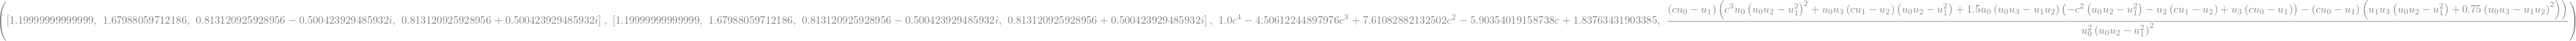

In [ ]:
# Substitute moments into characteristic polynomial
subs_dict_equilibrium = {
    u0: moments[0],
    u1: moments[1],
    u2: moments[2],
    u3: moments[3]
}

P_subs = simplify(P.subs(subs_dict_equilibrium))

# Calculate roots
roots = solve(Eq(P_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
print(roots_subs)

In [11]:
print(latex(P_subs))

1.0 c^{4} - 4.50612244897976 c^{3} + 7.61082882132502 c^{2} - 5.90354019158738 c + 1.83763431903385


In [12]:
print(latex(roots_subs))

\left[ 1.19999999999999, \  1.67988059712186, \  0.813120925928956 - 0.500423929485932 i, \  0.813120925928956 + 0.500423929485932 i\right]
